In [75]:
%loadlibs
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from torch.func import jacrev
from pcgrad import PCGrad
import pandas as pd
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


We work with a non-linear, stationary system
\begin{equation}
    \begin{cases}
\dot{x} = (x-\mu) + (y-\mu^2),\\[4pt]
\dot{y} = -(y-\mu^2) - (x-\mu)^3,
\end{cases}
\qquad \mu\in\mathbb{R}.
\end{equation}
with $\mu$ a constant

In [160]:
T_MAX = 3.

In [206]:
def get_sol(interval, c_i, mu=1.):
    def xdot(t, z):
        x, y = z
        dxdt = (x - mu) + (y - mu**2)
        dydt = -(y - mu**2) - (x - mu)**3
        return [dxdt, dydt]
    sol = solve_ivp(xdot, interval, c_i, t_eval=np.linspace(interval[0], interval[1], 1000))
    return np.concatenate([sol.t.reshape((1, sol.t.shape[0])), sol.y[0:1], sol.y[1:2]])
    
def true_trajectory(interval: list[int], c_i: list[int], mu=1., ax=None, color='black') -> None:
    sol = get_sol(interval, c_i, mu)
    if ax:
        ax.plot(sol[1, :], sol[2, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", linestyle='dashed', color=color)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
    else:
        plt.plot(sol[1, :], sol[2, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", linestyle='dashed', color=color)
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")

def true_phase_portrait(mu=1., ax=None):
    lim = 3.5
    x1, x2 = np.meshgrid(np.arange(-lim, lim, 0.4), np.arange(-lim, lim, 0.2))
    x1_values = (x1-mu) + (x2-mu**2)
    x2_values = (-(x2-mu**2) - (x1-mu)**3)

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    if not ax:
        plt.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        plt.xlim([-lim, lim])
        plt.ylim([-lim, lim])
        plt.grid()
    else:
        ax.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        ax.set_xlim([-lim, lim])
        ax.set_ylim([-lim, lim])
        ax.set_title("Reference")

def get_roots(mu, tol=6):
    def system(z):
        x, y = z
        dxdt = (x - mu) + (y - mu**2)
        dydt = -(y - mu**2) - (x - mu)**3
        return [dxdt, dydt]
    lim = 3
    sol, info, ier, msg = fsolve(system, [0., 0.], full_output=True)
    return sol

In [207]:
def get_references():
    references = []
    np.random.seed(0)
    T_MAX_REFERENCE = 5.
    N_POINTS_REFERENCE = 1000
    c_is_reference = (np.random.random(size=(N_POINTS_REFERENCE, 2))-0.5) * 10
    for c_i in c_is_reference:
        t0 = np.random.random()*T_MAX_REFERENCE
        references.append(get_sol((t0, T_MAX_REFERENCE+t0), c_i))
    return torch.tensor(np.array(references), dtype=torch.float32)

def evaluate_model_on_trajectories(model, references):
    error = 0
    with torch.no_grad():
        for i in range(references.shape[0]):
            t = references[i, 0, :].unsqueeze(1)
            t0 = references[i, 0, 0:1] * torch.ones_like(t)
            x1_0 = references[i, 1, 0:1] * torch.ones_like(t)
            x2_0 = references[i, 2, 0:1] * torch.ones_like(t)
            y_hat = model(t, t0, x1_0, x2_0)
            y = references[i, 1:].T
            error += ((y_hat-y).abs()).mean()
    return error.item()/references.shape[0]

In [208]:
def g_at_tau0(model, x1_0, x2_0):
    ones = torch.ones_like(x1_0)
    return model(ones, 0*ones, x1_0, x2_0).cpu()

def residual_np(xy, model, t0_scalar):
    x1_0 = torch.tensor([[xy[0]]], dtype=torch.float32)
    x2_0 = torch.tensor([[xy[1]]], dtype=torch.float32)
    with torch.no_grad():
        F = g_at_tau0(model, x1_0, x2_0)
    return F.squeeze(0).numpy()

def get_distance_with_true_fixed_point(model, mu):
    root = fsolve(residual_np, x0=[0, 0], args=(model, 0.0))
    x1_0, x2_0 = get_roots(mu)
    return ((root[0]-x1_0)**2 + (root[1]-x2_0)**2)**0.5

In [209]:
def model_trajectory(model, interval: list[int], c_i: list[int], ax=None, color='black') -> None:
    t_eval = torch.linspace(interval[0], interval[1], 250).unsqueeze(-1)
    x1x2 = model(t_eval, torch.zeros_like(t_eval), torch.ones_like(t_eval)*c_i[0], torch.ones_like(t_eval)*c_i[1]).detach().cpu().squeeze().numpy()
    x1, x2 = x1x2[:, 0], x1x2[:, 1]
    if ax:
        ax.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", color=color)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
    else:
        plt.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", color=color)
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")

def model_phase_portrait(model, ax, t=1., opacity=1.):
    x1_0, x2_0 = torch.meshgrid(torch.arange(-1.5, 1.6, 0.2), torch.arange(-1.5, 1.6, 0.2))
    x1_0 = x1_0.flatten().unsqueeze(-1)
    x2_0 = x2_0.flatten().unsqueeze(-1)
    t = torch.ones_like(x1_0, requires_grad=True)*t
    x1x2 = model(t, t.detach(), x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1_values = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()
    x2_values = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    ax.quiver(x1_0.cpu().detach().squeeze(), x2_0.cpu().detach().squeeze(), x1_normalized, x2_normalized, scale=vector_scale, alpha=opacity)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_title(f"t: {t[0].item()}")

def display_results(model, mu):
    c_i1, c_i2 = np.meshgrid(np.arange(-1, 1.5, 0.5), np.arange(-1, 1.5, 0.5))
    c_is = (np.array(list(zip(c_i1.flatten(), c_i2.flatten()))))
    fig, ax = plt.subplots(1, 3, figsize=(30, 10))
    colors = plt.cm.magma(np.linspace(0, 1, len(c_is)))

    for c_i, color in zip(c_is, colors):
        model_trajectory(model, (0, T_MAX), c_i, ax=ax[0], color=color)
        true_trajectory((0, T_MAX), c_i, mu, ax=ax[0], color=color)
    ax[0].set_xlim(-1.5, 1.5)
    ax[0].set_ylim(-1.5, 1.5)
    ax[0].grid()
    for t in np.arange(0, T_MAX, .5):
        model_phase_portrait(model, ax[1], t, opacity=t/T_MAX)
    ax[1].set_title("Phase portrait of the model through time")
    ax[1].legend([f"t={t}" for t in np.arange(0, T_MAX, .5)])
    true_phase_portrait(mu, ax[2])
    model_phase_portrait(model, ax[2], 0, opacity=0.5)
    ax[2].legend(["Reference", "Model at t=0"])
    ax[2].set_title("Reference and model")

In [210]:
class XSinLayer(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.sin(x) * x
        
class TransitionPINN(nn.Module):
    def __init__(self, layer_size=256):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l5 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = XSinLayer()

    def forward(self, t, t0, x1_0, x2_0):
        inputs = torch.concatenate([t, t0, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.activation(self.l5(x))
        return (t-t0) * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

def loss_physics(model, mu, t, t0, x1_0, x2_0):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dx1_dt = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2_dt = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    loss_x1 = ((dx1_dt - ((x1-mu)+(x2 - mu**2)))**2).mean()
    loss_x2 = ((dx2_dt - (-(x2-mu**2)-(x1-mu)**3))**2).mean()
    return loss_x1 + loss_x2

In [232]:
def train_model(seed: int, mu, n_epochs, n_points, verbose=True):
    torch.random.manual_seed(seed)
    model_1 = TransitionPINN()
    optimizer = optim.Adam(model_1.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    pbar = tqdm(range(n_epochs)) if verbose else range(n_epochs)
    for _ in pbar:
        optimizer.zero_grad()
        t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
        t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
        x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 6.
        x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 6.
        loss = loss_physics(model_1, mu, t, t0, x1_0, x2_0)
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        if verbose:
            pbar.set_description(f"Loss Physics: {loss.item():.4e}")
    return model_1

In [233]:
class TransitionPINN2(nn.Module):
    def __init__(self, layer_size=256):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l5 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = XSinLayer()

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        inputs = torch.concatenate([tau, tau**1.1, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.activation(self.l5(x))
        return tau * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

In [234]:
def composition_loss(model, t, t0, t1, x1_0, x2_0):
    x1 = model(t, t0, x1_0, x2_0)
    x1x2_1 = model(t1, t0, x1_0, x2_0)
    x1_1, x2_1 = x1x2_1[:, 0:1].detach(), x1x2_1[:, 1:2].detach()
    x2 = model(t, t1, x1_1, x2_1)
    return ((x2-x1)**2).mean()

In [247]:
def train_model2(seed: int, mu, n_epochs, n_points, verbose=True):
    torch.random.manual_seed(seed)
    model = TransitionPINN2()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    pbar = tqdm(range(n_epochs)) if verbose else range(n_epochs)
    for _ in pbar:
        optimizer.zero_grad()
        t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
        t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
        x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
        x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
        loss1 = loss_physics(model, mu, t, t0, x1_0, x2_0)
        t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (t-t0)
        loss2 = composition_loss(model, t, t0, t1, x1_0, x2_0)
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        if verbose:
            pbar.set_description(f"Loss Physics: {loss1.item():.4e}, Loss Composition: {loss2.item():.4e}")
    return model

In [248]:
mu = 0.5
n_points = 1000
n_epochs = 2000
mus = np.arange(-2, 2, 0.4)

In [246]:
results = []
for mu in tqdm(mus):
    model_1 = train_model(0, mu, n_epochs, n_points, verbose=True)
    model_2 = train_model2(0, mu, n_epochs, n_points, verbose=True)
    results.append([get_distance_with_true_fixed_point(model_1, mu), get_distance_with_true_fixed_point(model_2, mu)])

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

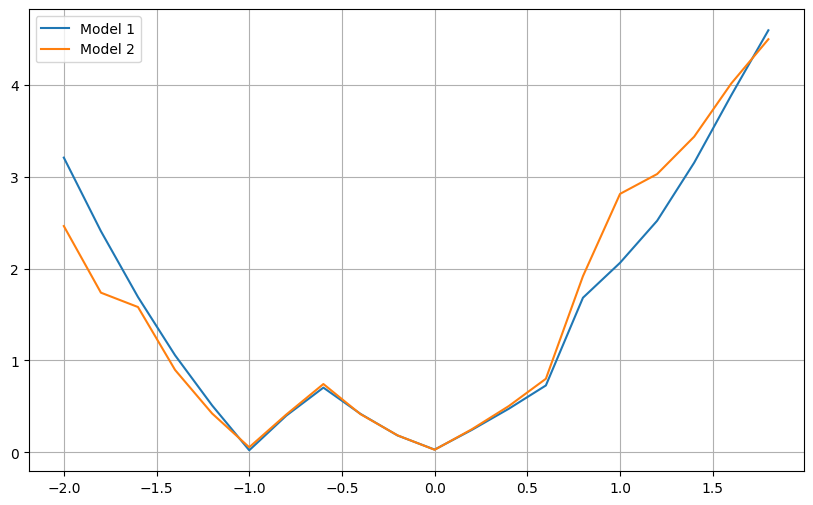

In [241]:
plt.figure(figsize=(10, 6))
plt.plot(mus, np.array(results))
plt.legend(["Model 1", "Model 2"])
plt.grid()
plt.show()